In [2]:
# ============================================
# 보충 EDA ② - 골목·전통시장 매출 결정 요인 확인
# 목적: "유동인구 늘려도 매출 안 오른다" → 실제로 뭐가 결정하는지 수치화
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 추정매출 로드
매출_파일들 = glob.glob('../data/03_추정매출/*.csv')
매출_리스트 = []
for 파일 in 매출_파일들:
    if '2025' in 파일:
        continue
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    매출_리스트.append(df)
sales = pd.concat(매출_리스트, ignore_index=True)

# 영역상권 로드 (좌표 포함)
area = pd.read_csv(
    '../data/영역상권/서울시 상권분석서비스(영역-상권).csv',
    encoding='cp949'
)

# 길단위인구 로드
floating = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 직장인구 로드
df_직장 = pd.read_csv(
    '../data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv',
    encoding='cp949'
)

# 상주인구 로드
df_상주 = pd.read_csv(
    '../data/07_상주인구/서울시 상권분석서비스(상주인구-상권).csv',
    encoding='cp949'
)

print(f'추정매출: {sales.shape}')
print(f'영역상권: {area.shape}')
print(f'유동인구: {floating.shape}')
print(f'직장인구: {df_직장.shape}')
print(f'상주인구: {df_상주.shape}')

추정매출: (435849, 62)
영역상권: (1650, 11)
유동인구: (46184, 27)
직장인구: (45840, 26)
상주인구: (40812, 29)


In [3]:
# ============================================
# 데이터 병합
# ============================================

# 분석 기간 필터링 (2019Q1~2024Q4)
sales = sales[sales['기준_년분기_코드'] < 20250]

# 상권 단위 매출 집계
sales_agg = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
).agg(
    당월_매출=('당월_매출_금액', 'sum'),
    당월_건수=('당월_매출_건수', 'sum')
).reset_index()

sales_agg['객단가'] = sales_agg['당월_매출'] / sales_agg['당월_건수'].replace(0, np.nan)

# 영역상권 병합 (좌표)
sales_agg = sales_agg.merge(
    area[['상권_코드', '자치구_코드_명', '엑스좌표_값', '와이좌표_값']],
    on='상권_코드', how='left'
)

# 유동인구 병합
sales_agg = sales_agg.merge(
    floating[['기준_년분기_코드', '상권_코드', '총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 직장인구 병합
sales_agg = sales_agg.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 상주인구 병합
sales_agg = sales_agg.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

print(f'병합 완료: {sales_agg.shape}')
print(f'상권 유형: {sales_agg["상권_구분_코드_명"].unique()}')
print(f'결측치 확인:')
print(sales_agg[['총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']].isna().sum())

병합 완료: (31382, 12)
상권 유형: <StringArray>
['관광특구', '골목상권', '발달상권', '전통시장']
Length: 4, dtype: str
결측치 확인:
총_유동인구_수      11
총_직장_인구_수    173
총_상주인구_수     312
dtype: int64


In [4]:
# ============================================
# 골목·전통시장 한정 필터링
# ============================================

골목_전통 = sales_agg[
    sales_agg['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
].copy()

print(f'골목+전통시장 데이터: {골목_전통.shape}')
print(골목_전통['상권_구분_코드_명'].value_counts())

골목+전통시장 데이터: (26282, 12)
상권_구분_코드_명
골목상권    20697
전통시장     5585
Name: count, dtype: int64


In [6]:
# ============================================
# 핵심 변수별 매출 상관관계
# 목적: 유동인구 vs 직장인구 vs 상주인구 중 뭐가 매출을 결정하는지
# ============================================

# 비교할 변수 3개 정의
변수들 = ['총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']

print(' 골목상권 + 전통시장 — 매출 결정 요인 상관계수')
print('=' * 50)

# 골목상권, 전통시장 각각 반복
for 유형 in ['골목상권', '전통시장']:
    
    # 해당 유형만 필터링
    sub = 골목_전통[골목_전통['상권_구분_코드_명'] == 유형]
    
    print(f'\n {유형}')  
    
    # 변수별 매출 상관계수 계산
    for 변수 in 변수들:
        # 결측치 제거 후 상관계수 계산 (0행:매출, 1열:변수)
        corr = sub[['당월_매출', 변수]].dropna().corr().iloc[0, 1]
        print(f'  {변수:<15} × 매출 상관계수: {corr:.3f}')

 골목상권 + 전통시장 — 매출 결정 요인 상관계수

 골목상권
  총_유동인구_수        × 매출 상관계수: 0.443
  총_직장_인구_수       × 매출 상관계수: 0.414
  총_상주인구_수        × 매출 상관계수: 0.442

 전통시장
  총_유동인구_수        × 매출 상관계수: 0.296
  총_직장_인구_수       × 매출 상관계수: 0.305
  총_상주인구_수        × 매출 상관계수: 0.105


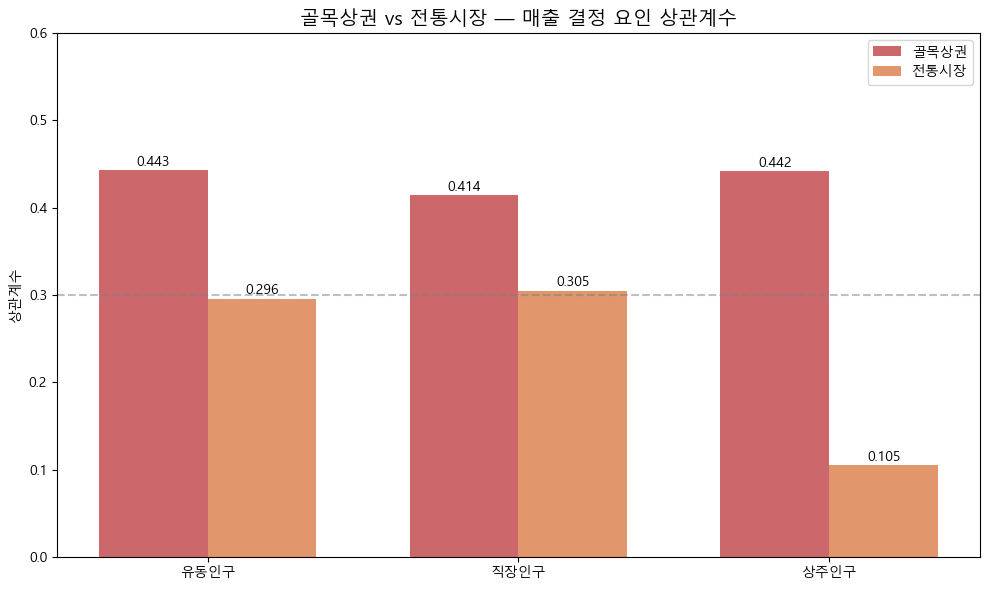

In [7]:
# ============================================
# 매출 결정 요인 상관계수 비교 막대그래프
# ============================================

# 상관계수 데이터 정리
변수_라벨 = ['유동인구', '직장인구', '상주인구']
골목_corr = [0.443, 0.414, 0.442]
전통_corr = [0.296, 0.305, 0.105]

x = np.arange(len(변수_라벨))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 막대 그래프
bars1 = ax.bar(x - width/2, 골목_corr, width, label='골목상권', color='#C44E52', alpha=0.85)
bars2 = ax.bar(x + width/2, 전통_corr, width, label='전통시장', color='#DD8452', alpha=0.85)

# 수치 표시
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

ax.set_title('골목상권 vs 전통시장 — 매출 결정 요인 상관계수', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(변수_라벨)
ax.set_ylabel('상관계수')
ax.set_ylim(0, 0.6)
ax.legend()
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='기준선 0.3')

plt.tight_layout()
plt.show()

In [9]:
# 점포 합본 로드
df_점포 = pd.read_csv(
    '../data/점포_합본.csv',
    encoding='utf-8', low_memory=False
)

# 분석 기간 필터링
df_점포 = df_점포[df_점포['기준_년분기_코드'] < 20250]

print(f'점포 데이터: {df_점포.shape}')
print(df_점포.columns.tolist())

점포 데이터: (1831925, 15)
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수', '연도']


In [10]:
# ============================================
# 상권 유형별 업종 다양성 비교
# 목적: 업종구성이 매출을 결정하는지 확인
# ============================================

# 상권 유형별 평균 업종수 계산
# nunique = 고유한 업종 수 (다양성 지표)
업종다양성 = df_점포.groupby(
    ['상권_코드', '상권_구분_코드_명']
)['서비스_업종_코드'].nunique().reset_index()

업종다양성.columns = ['상권_코드', '상권_구분_코드_명', '업종수']

# 상권 유형별 평균 업종수
평균_업종수 = 업종다양성.groupby('상권_구분_코드_명')['업종수'].mean().round(1)
print('상권 유형별 평균 업종수')
print(평균_업종수.sort_values(ascending=False))

상권 유형별 평균 업종수
상권_구분_코드_명
관광특구    89.8
발달상권    80.0
골목상권    53.6
전통시장    44.0
Name: 업종수, dtype: float64


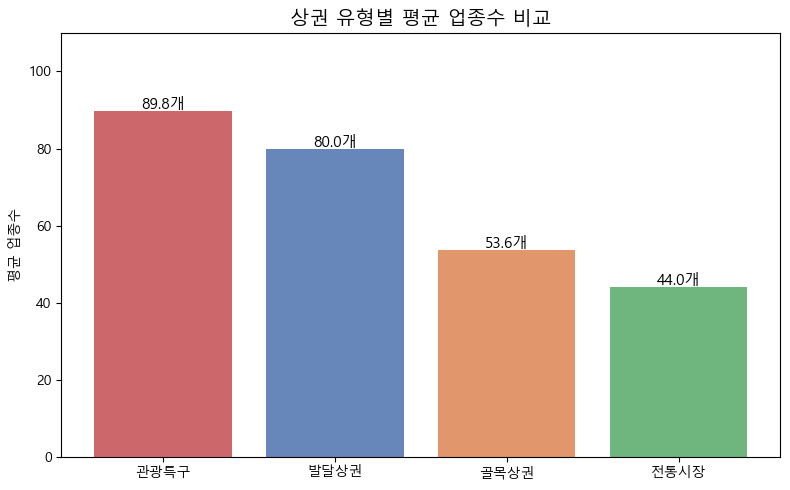

In [11]:
# ============================================
# 상권 유형별 평균 업종수 막대그래프
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#C44E52', '#4C72B0', '#DD8452', '#55A868']
유형순서 = ['관광특구', '발달상권', '골목상권', '전통시장']
값 = [평균_업종수[유형] for 유형 in 유형순서]

bars = ax.bar(유형순서, 값, color=colors, alpha=0.85)

# 수치 표시
for bar, val in zip(bars, 값):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}개', ha='center', fontsize=11)

ax.set_title('상권 유형별 평균 업종수 비교', fontsize=14)
ax.set_ylabel('평균 업종수')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

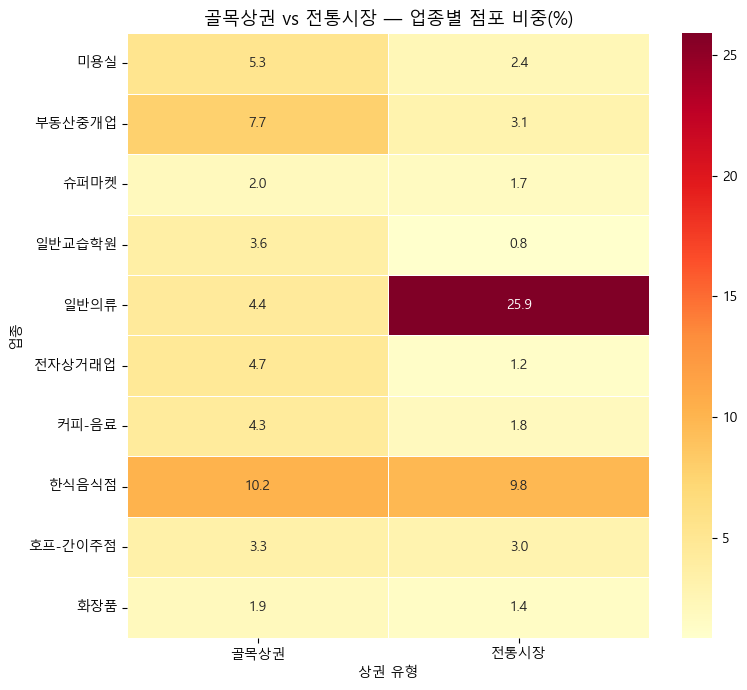

In [12]:
# ============================================
# 골목·전통시장 TOP 10 업종 매출 비중 비교
# 목적: 업종구성이 상권 유형별로 어떻게 다른지
# ============================================

# 골목·전통시장 필터링
골목_전통_점포 = df_점포[
    df_점포['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
]

# 상권 유형별 업종별 점포수 합산
업종_비중 = 골목_전통_점포.groupby(
    ['상권_구분_코드_명', '서비스_업종_코드_명']
)['점포_수'].sum().reset_index()

# 전체 점포수 대비 비중 계산
총점포 = 업종_비중.groupby('상권_구분_코드_명')['점포_수'].transform('sum')
업종_비중['비중'] = (업종_비중['점포_수'] / 총점포 * 100).round(2)

# 골목상권 TOP 10 업종
골목_top10 = (
    업종_비중[업종_비중['상권_구분_코드_명'] == '골목상권']
    .nlargest(10, '비중')['서비스_업종_코드_명']
    .tolist()
)

# TOP 10 업종만 피벗
pivot = 업종_비중[
    업종_비중['서비스_업종_코드_명'].isin(골목_top10)
].pivot(
    index='서비스_업종_코드_명',
    columns='상권_구분_코드_명',
    values='비중'
).fillna(0)

# 히트맵
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('골목상권 vs 전통시장 — 업종별 점포 비중(%)', fontsize=13)
ax.set_xlabel('상권 유형')
ax.set_ylabel('업종')
plt.tight_layout()
plt.show()